<img src="ost_logo.png" width="240" align="right"/>
<div style="text-align: left"> <b> Machine Learning </b> <br> MSE FTP MachLe <br> 
<a href="mailto:christoph.wuersch@ost.ch"> Christoph Würsch </a> </div>

## Lab 4, A2: Feature Selection on the Wisconsin Breast Cancer Dataset

In [1]:
%matplotlib inline
#from preamble import *

# from IPython.display import set_matplotlib_formats, display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 300
plt.rcParams['image.cmap'] = "viridis"
plt.rcParams['image.interpolation'] = "none"
plt.rcParams['savefig.bbox'] = "tight"
plt.rcParams['lines.linewidth'] = 2

from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectPercentile
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
print(cancer.target_names)
print(cancer.feature_names)


['malignant' 'benign']
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


### (a) Plotting Histograms

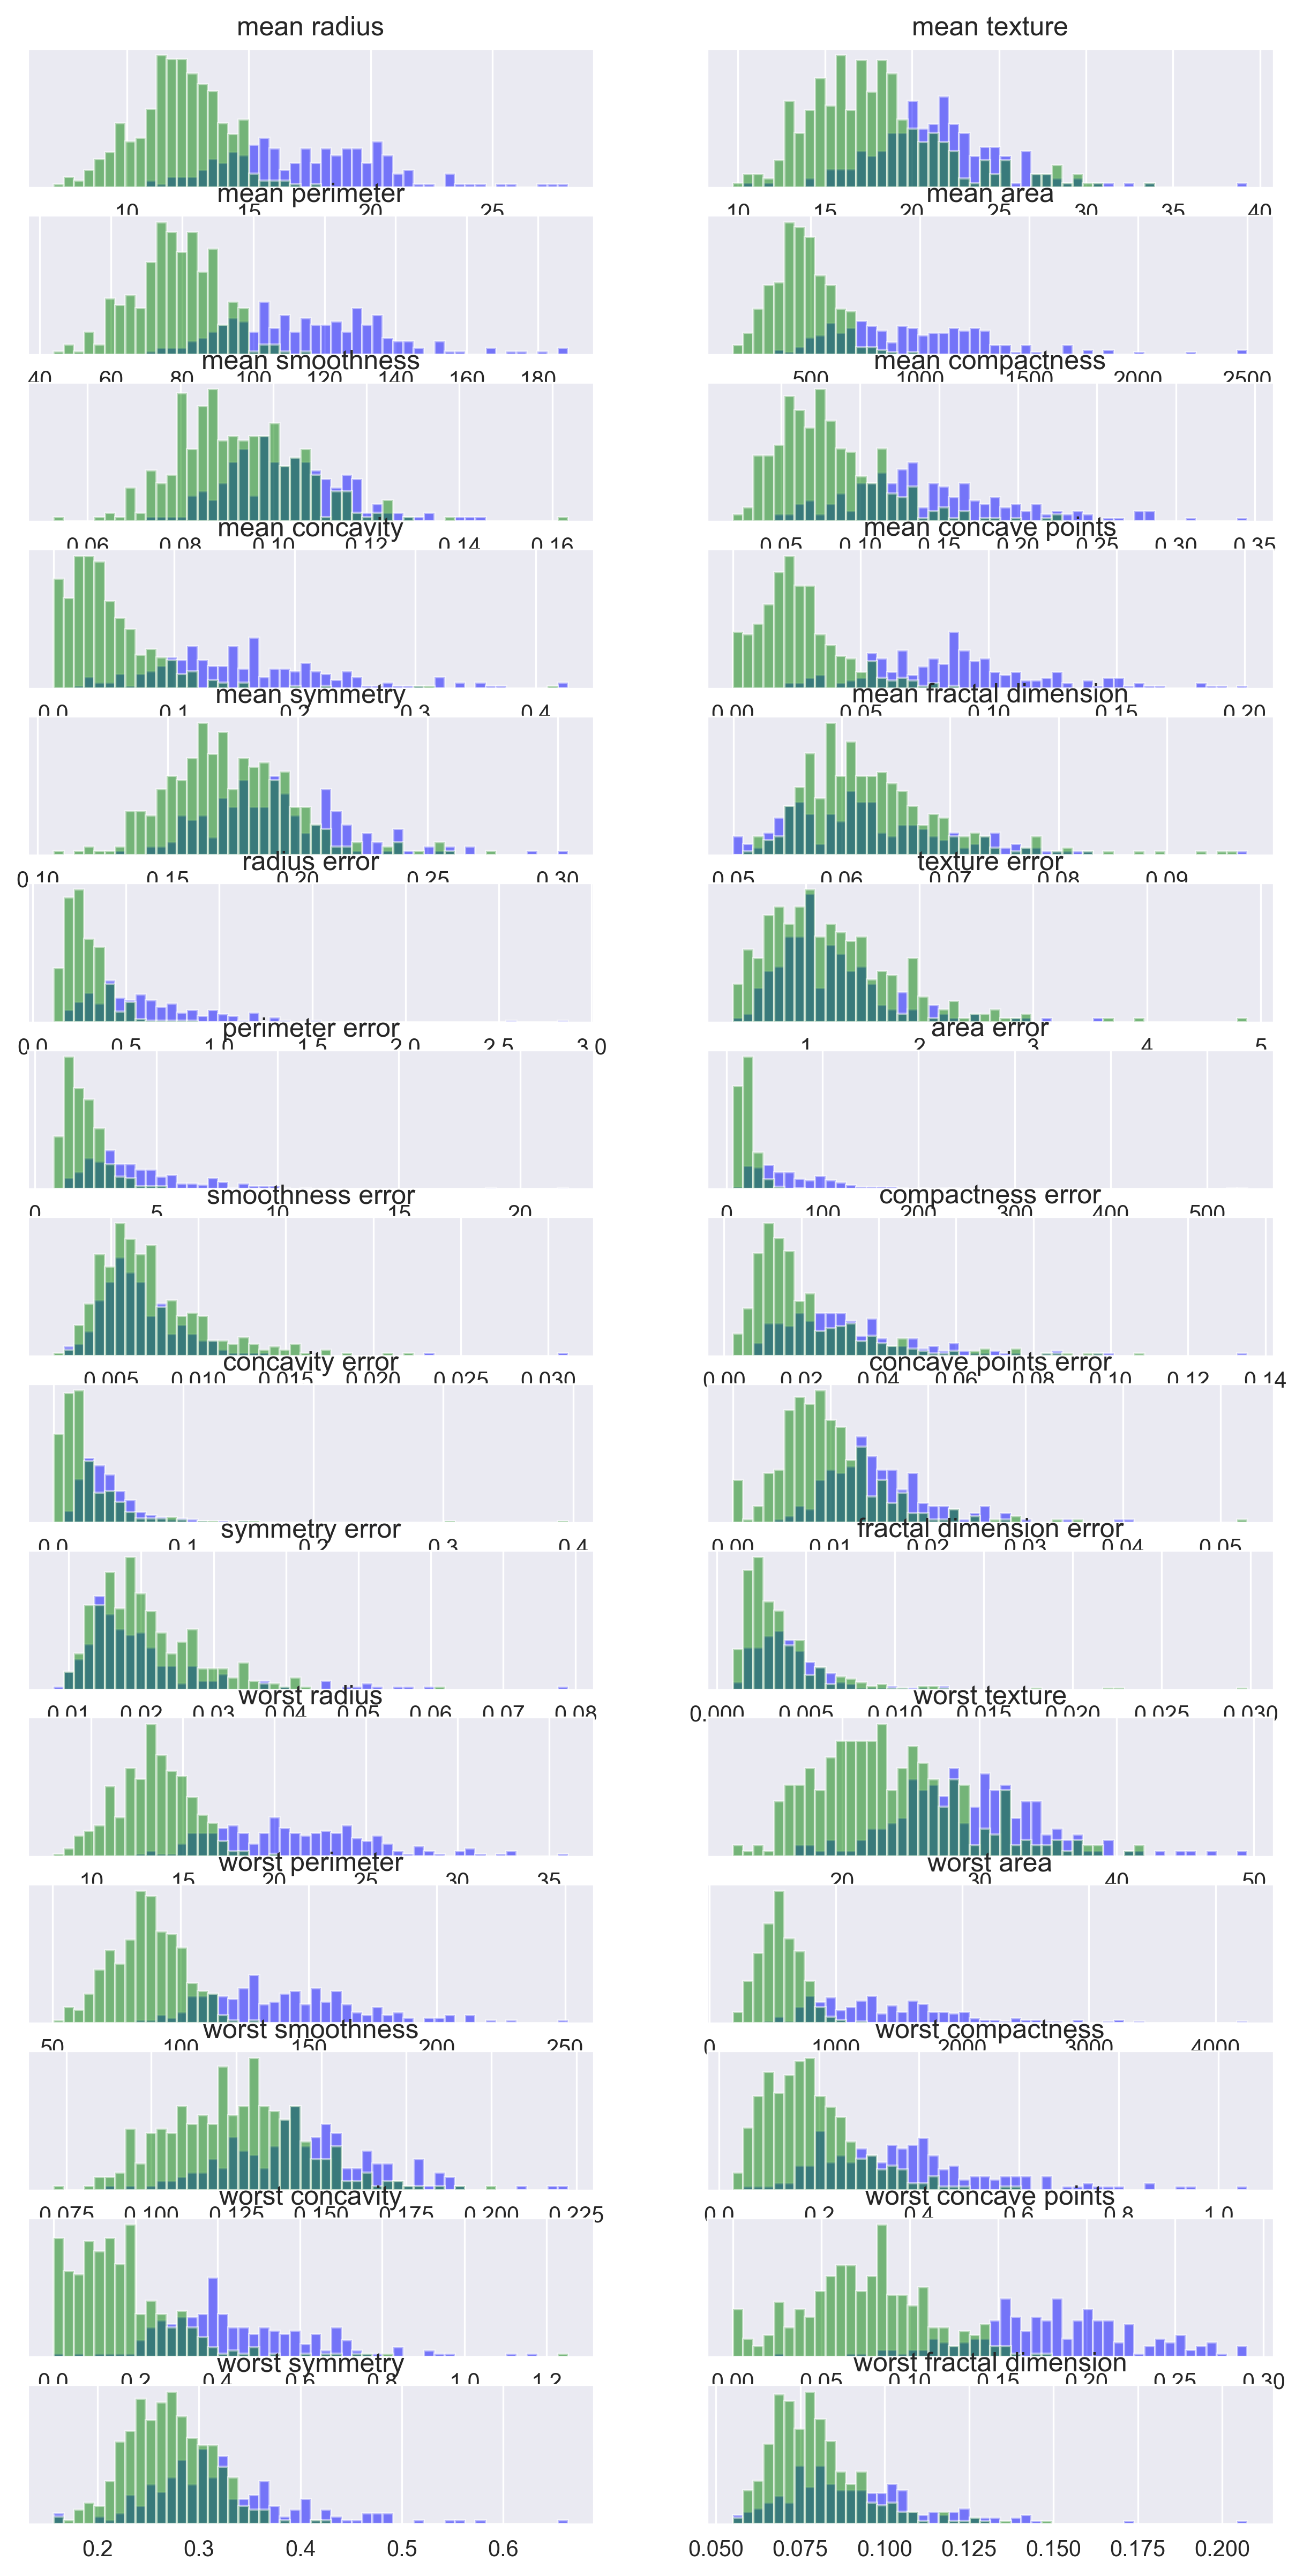

In [2]:
fig, axes = plt.subplots(15, 2, figsize=(10, 20))
malignant = cancer.data[cancer.target == 0]
benign = cancer.data[cancer.target == 1]
ax = axes.ravel()
for i in range(30):
    _, bins = np.histogram(cancer.data[:, i], bins=50)
    ax[i].hist(malignant[:, i], bins=bins, color='b', alpha=.5)
    ax[i].hist(benign[:, i], bins=bins, color='g', alpha=.5)
    ax[i].set_title(cancer.feature_names[i])
    ax[i].set_yticks(())
    ax[0].set_xlabel("Größe des Merkmals")

### (b) Automatic Feature Selection: Univariate statistics (F-test, ANOVA)

[Description](https://scikit-learn.org/stable/modules/feature_selection.html#univariate-feature-selection)

**Univariate feature selection works by selecting the best features based on univariate statistical tests**. It can be seen as a preprocessing step to an estimator. Scikit-learn exposes feature selection routines as objects that implement the `transform` method. These objects take as input a scoring function that returns univariate scores and p-values (or only scores for `SelectKBest` and `SelectPercentile`):
- For regression: `r_regression, f_regression, mutual_info_regression`
- For classification: `chi2, f_classif, mutual_info_classif`

The methods based on **F-test** estimate the degree of linear dependency between two random variables. 

`f_regression`: Univariate linear regression tests returning F-statistic and p-values. Quick linear model for testing the effect of a single regressor, sequentially for many regressors. This is done in 2 steps:

1. The **cross correlation** between each regressor and the target is computed using `r_regression` as:

`E[(X[:, i] - mean(X[:, i])) * (y - mean(y))] / (std(X[:, i]) * std(y))`

2. It is converted to an **F-score** and then to a p-value.

On the other hand, mutual information methods can capture any kind of statistical dependency, but being nonparametric, they require more samples for accurate estimation. Note that the $\chi^2$-test should only be applied to non-negative features, such as frequencies.





### Step 1: Computing Cross Correlation using `r_regression`

The formula you've mentioned for `r_regression`:
$$ \text{Correlation} =r^2= \frac{\mathbb{E}[(X[:, i] - \text{mean}(X[:, i])) \cdot (y - \text{mean}(y))]}{\text{std}(X[:, i]) \cdot \text{std}(y)} $$

- **Objective**: This step aims to compute the correlation coefficient between each regressor $(X[:, i]$ (i.e., each independent variable) and the target  $y$.
- **Method**: The formula calculates the expected (E) value of the product of deviations of $X[:, i]$ values and $y$ values from their respective means, normalized by the product of their standard deviations. This effectively computes the Pearson correlation coefficient for each regressor with the target, measuring the strength and direction of a linear relationship between them.

### Step 2: Converting to F-score and P-value

The correlation coefficient obtained from step 1 can be converted to an F-score and then to a p-value. This process involves two transformations:

1. **Correlation to F-score**: The square of the correlation coefficient $r^2$ is related to the F-score in regression analysis. Specifically, for a simple linear regression, the F-score can be calculated from the correlation coefficient as follows:

$$ \boxed{ F = \frac{r^2 \cdot (n - 2)}{1 - r^2}} $$

where \(n\) is the number of observations. This formula is derived from the relationship between the total variation, the explained variation, and the unexplained variation in the context of a simple linear regression. The F-score here tests whether the observed relationship between the variables is statistically significant.

2. **F-score to P-value**: *The F-score follows an F-distribution under the null hypothesis* (which typically states that there is no relationship between the independent and dependent variables). The p-value is then calculated based on the F-distribution, given the degrees of freedom for the model and the error. The p-value indicates the probability of observing an F-score as extreme as, or more extreme than, the one calculated if the null hypothesis were true.

The process described leverages the linear correlation between variables as an intermediary step to perform an F-test, allowing for the estimation of the significance of each variable in explaining the variation in the dependent variable. This method is particularly useful for feature selection in linear regression models, enabling the identification of the most important predictors among a potentially large set of variables.




### F-Distribution

- The F-distribution is a continuous probability distribution that arises in statistical analysis, particularly in the context of variance analysis and hypothesis testing. It plays a crucial role in tests of significance for comparing variances and assessing the overall fit of regression models, among other applications. Here's a detailed explanation:
- The F-distribution, also known as the **Snedecor's F distribution** or the **Fisher-Snedecor** distribution, is defined for positive real numbers and is used primarily to compare variances. It is the distribution of the ratio of two independent chi-squared variates, each divided by their respective degrees of freedom.

Consider two independent random variables, $U$ and $V$, which follow $\chi^2$ distributions with $d_1$ and $d_2$ degrees of freedom, respectively. **The F-distribution is the distribution of the ratio of two normalized, chi-squared random variables:**

$$ F = \frac{U/d_1}{V/d_2} $$

where:
- $U/d_1$ is a chi-squared variable divided by its degrees of freedom ($d_1$).
- $V/d_2$ is another chi-squared variable divided by its degrees of freedom ($d_2$).

#### Properties
- **Shape**: The shape of the F-distribution depends on the degrees of freedom, $d_1$ and $d_2$, of the numerator and the denominator, respectively. It is positively skewed, and as the degrees of freedom increase, it approaches a normal distribution.
- **Range**: The values of the F-distribution are always positive, ranging from 0 to $\infty$.
- **Mean and Variance**: 
- The mean of the F-distribution is $d_2 / (d_2 - 2)$ for $d_2 > 2$, and its 
- variance is given by $$ \frac{2d_2^2(d_1 + d_2 - 2)}{d_1(d_2 - 2)^2(d_2 - 4)} $$ for $d_2 > 4$.

### Applications

- **Analysis of Variance (ANOVA)**: The F-distribution is used in ANOVA to compare the variances between groups to determine if the groups are significantly different from each other.
- **Regression Analysis**: In the context of regression analysis, the F-test uses the F-distribution to test the overall significance of a regression model. This involves comparing the explained variance by the model to the unexplained variance.
- **Hypothesis Testing**: The F-distribution is utilized in hypothesis testing when comparing the variances of two populations, assuming that the populations are normally distributed.

The F-distribution's significance lies in its ability to handle ratios of variances, allowing statisticians to assess whether differences in variances are due to chance. In many statistical tests, such as ANOVA and the F-test in regression analysis, the F-distribution provides a critical value that can be compared to the test statistic to determine the p-value. This process helps in making decisions about the null hypothesis, such as whether to reject it in favor of the alternative hypothesis.





### F-Score in Regression Analysis: 

The F-score (or F-statistic) in the context of regression analysis is used in the context of an F-test. It's a way to test the overall significance of a regression model. The F-statistic is calculated from a ratio of two variances: the variance explained by the model (mean square regression) and the unexplained variance (mean square error). The formula for the F-statistic in a simple linear regression model is:

In [3]:

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0, test_size=.5)

# use f_classif (the default) and SelectPercentile to select 50% of features
# SelectPercentile removes all but a user-specified highest scoring percentage of features

select = SelectPercentile(percentile=50)
select.fit(X_train, y_train)
# transform training set
X_train_selected = select.transform(X_train)

print("X_train.shape: {}".format(X_train.shape))
print("X_train_selected.shape: {}".format(X_train_selected.shape))

X_train.shape: (284, 30)
X_train_selected.shape: (284, 15)


[ True False  True  True False  True  True  True False False  True False
  True  True False False False False False False  True False  True  True
 False  True  True  True False False]


([], [])

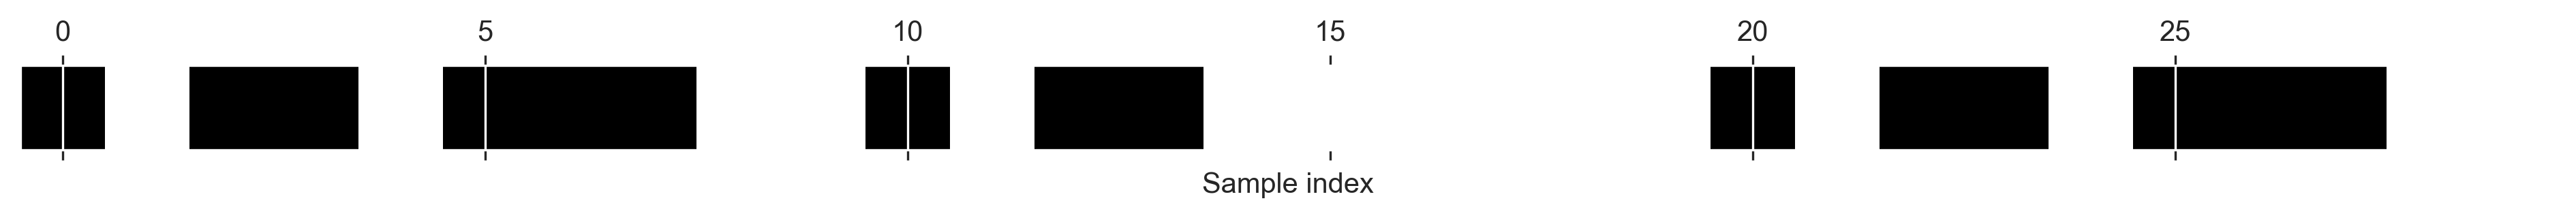

In [4]:
mask = select.get_support()
print(mask)
# visualize the mask. black is True, white is False
plt.matshow(mask.reshape(1, -1), cmap='gray_r')
plt.xlabel("Sample index")
plt.yticks(())

<BarContainer object of 30 artists>

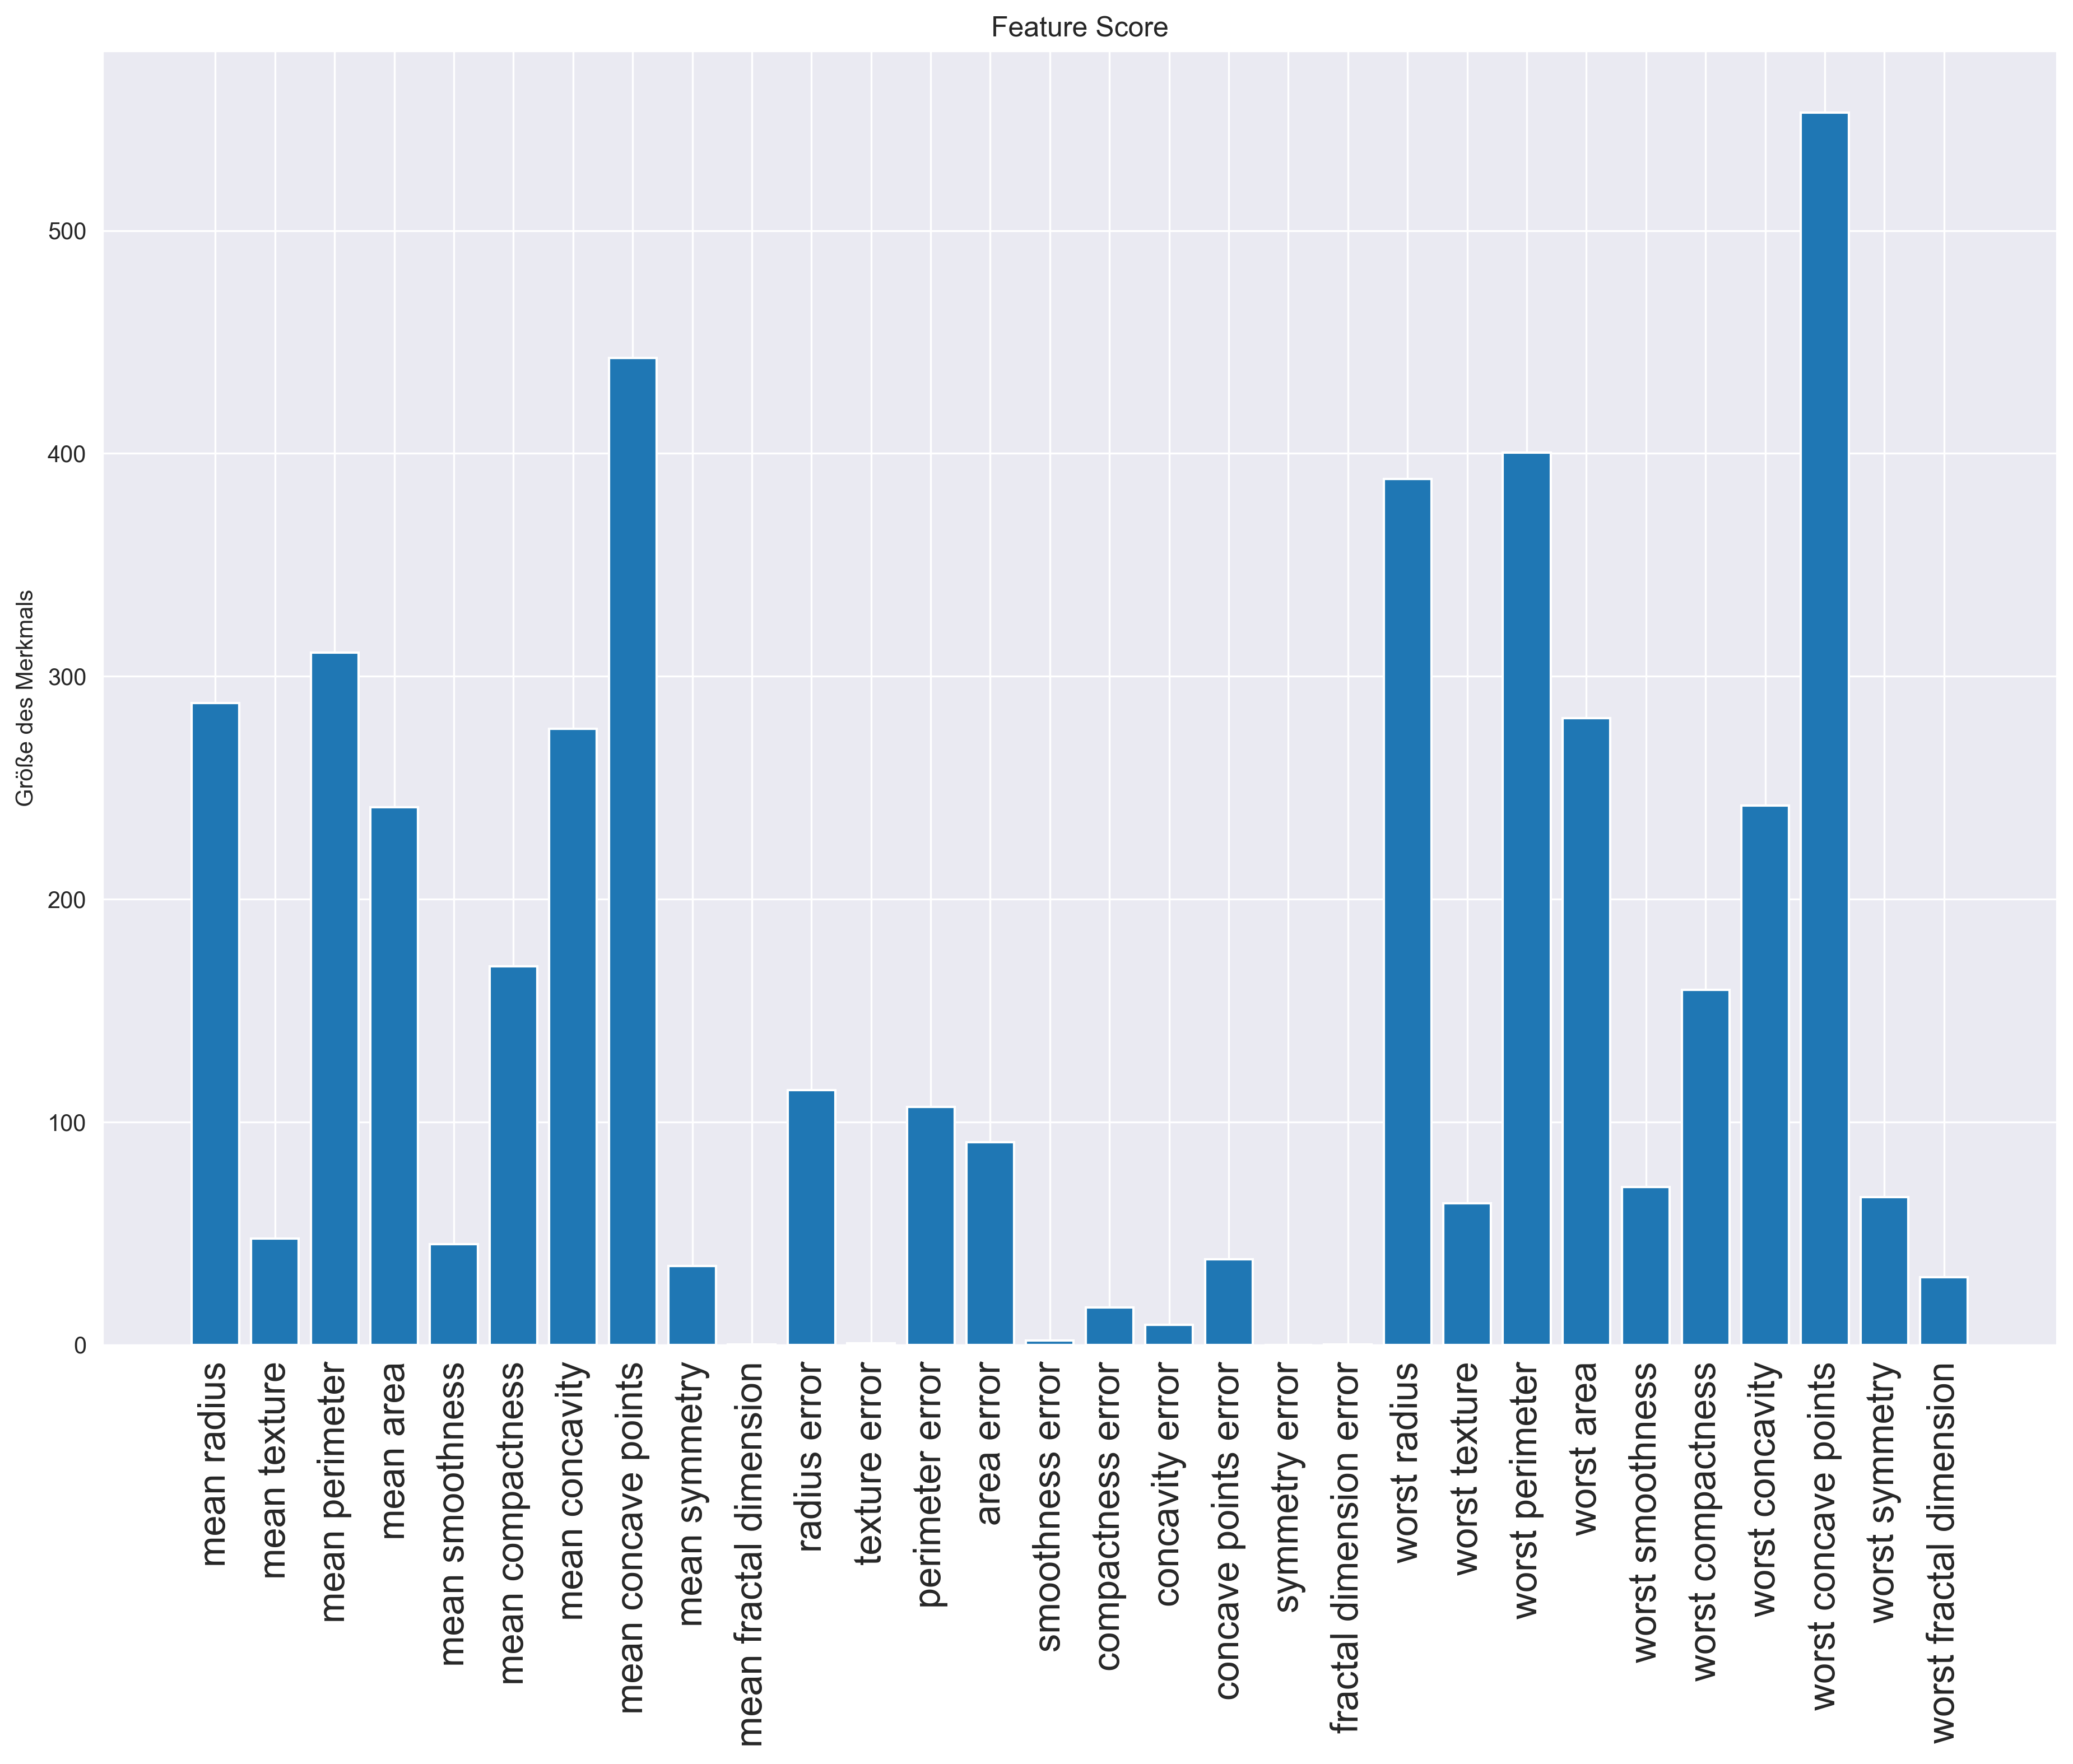

In [5]:

# visualize the mask. black is True, white is False
plt.figure(figsize=(15, 10))
n_features = cancer.data.shape[1]
plt.title("Feature Score")
plt.xticks(np.arange(n_features), cancer.feature_names, rotation=90, fontsize=16)
plt.ylabel("Größe des Merkmals")
plt.bar(range(n_features),select.scores_)

In [6]:
mask.reshape(1, -1)

array([[ True, False,  True,  True, False,  True,  True,  True, False,
        False,  True, False,  True,  True, False, False, False, False,
        False, False,  True, False,  True,  True, False,  True,  True,
         True, False, False]])

Let's fit now a linear model (logistic regression) model on the reduced input features to check the accuracy on the reduced input features.

In [7]:
from sklearn.linear_model import LogisticRegression

# transform test data
X_test_selected = select.transform(X_test)

lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
print("Score with all features: {:.3f}".format(lr.score(X_test, y_test)))
lr.fit(X_train_selected, y_train)
print("Score with only selected features: {:.3f}".format(
    lr.score(X_test_selected, y_test)))

Score with all features: 0.958
Score with only selected features: 0.954


### (c) Automatic Feature selection: Model-based Feature Selection using Random Forest Classifier

A random forest classifier gives back the relative feature importance. This score can be used to select the most important featurs.

Accuracy on training set: 0.961
Accuracy on test set: 0.926
Feature importances:
[0.         0.         0.         0.03070598 0.         0.
 0.02346761 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.08799043 0.
 0.         0.         0.         0.85783598 0.         0.        ]


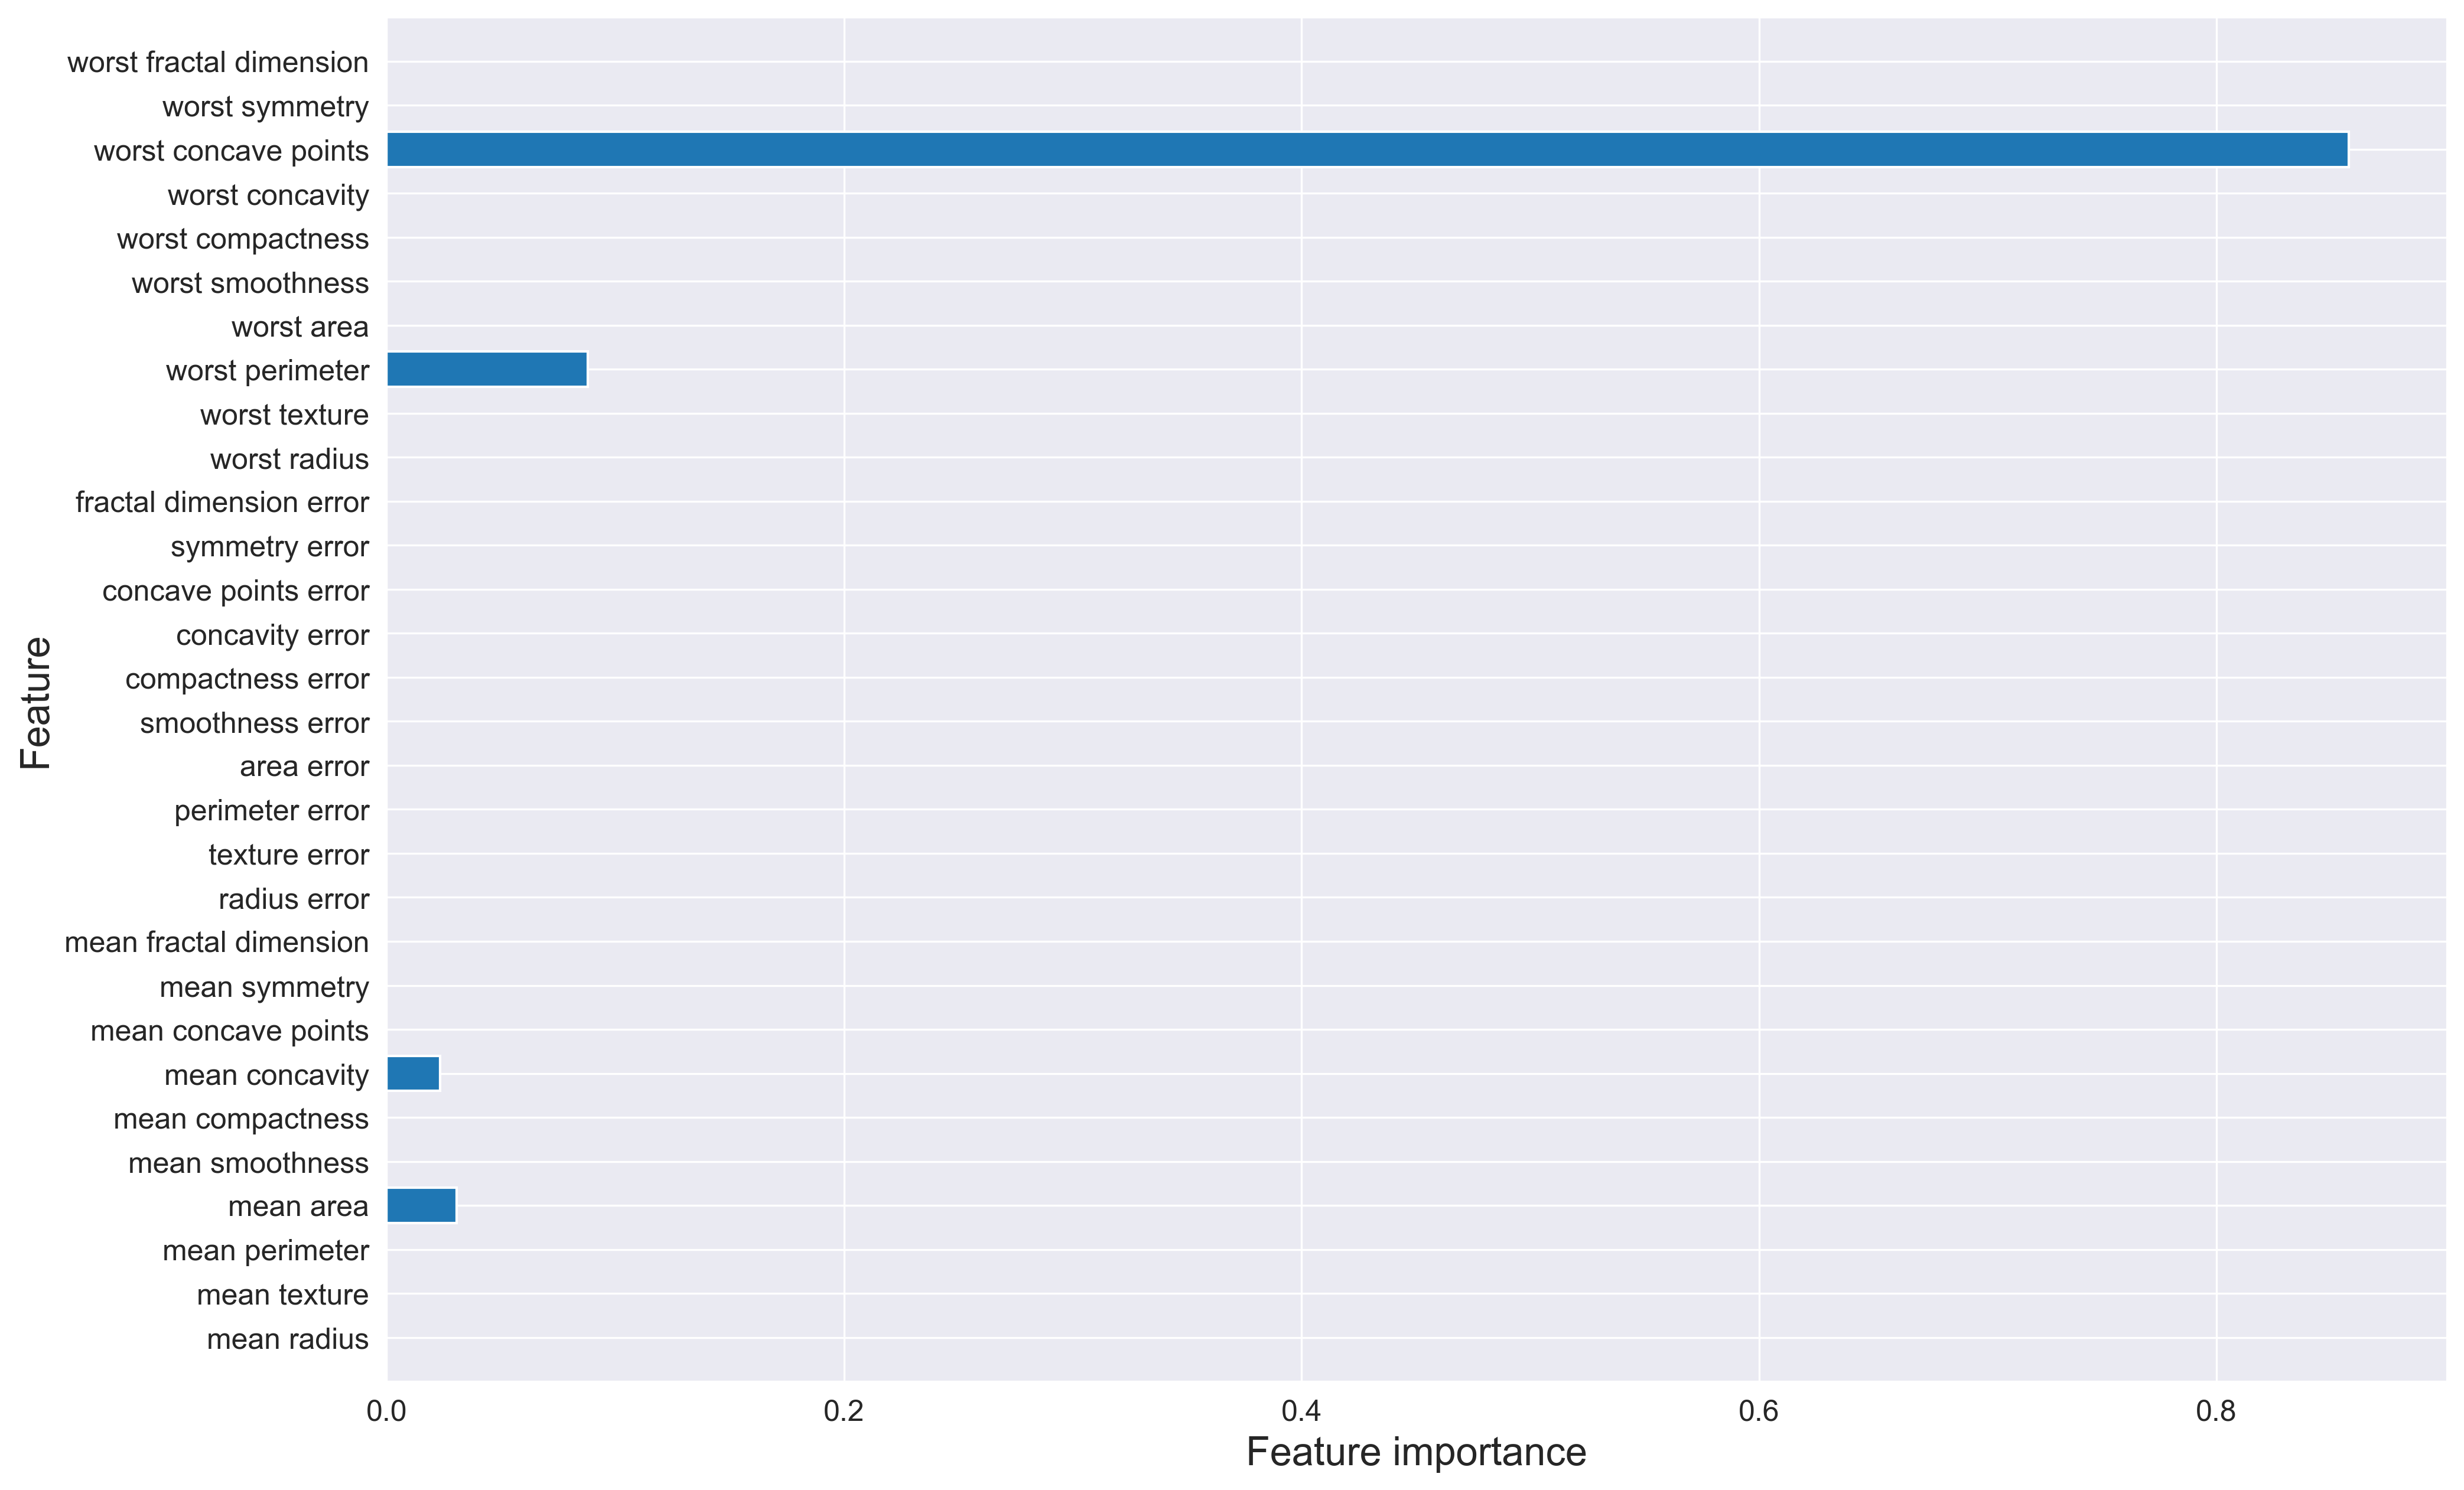

In [8]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=3, random_state=0)
tree.fit(X_train, y_train)

print("Accuracy on training set: {:.3f}".format(tree.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))

print("Feature importances:\n{}".format(tree.feature_importances_))

def plot_feature_importances_cancer(model):
    plt.figure(figsize=(15,10))
    n_features = cancer.data.shape[1]
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), cancer.feature_names,fontsize=12)
    plt.xticks(fontsize=12)
    
    plt.xlabel("Feature importance",fontsize=16)
    plt.ylabel("Feature",fontsize=16)
    plt.ylim(-1, n_features)

plot_feature_importances_cancer(tree)

### (d) Automatic Feature selection: Model-based Feature Selection using Random Forest Classifier


In [9]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
select = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=42),
    threshold="median")

In [10]:
select.fit(X_train, y_train)
X_train_l1 = select.transform(X_train)
print("X_train.shape: {}".format(X_train.shape))
print("X_train_l1.shape: {}".format(X_train_l1.shape))

X_train.shape: (284, 30)
X_train_l1.shape: (284, 15)


([], [])

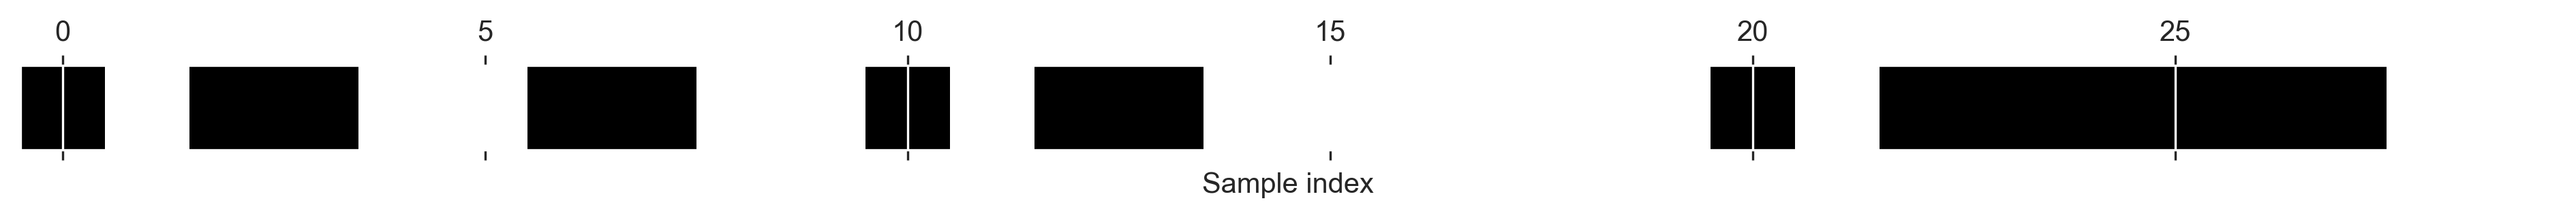

In [11]:
mask = select.get_support()
# visualize the mask. black is True, white is False
plt.matshow(mask.reshape(1, -1), cmap='gray_r')
plt.xlabel("Sample index")
plt.yticks(())

In [13]:
X_test_l1 = select.transform(X_test)
score = LogisticRegression(solver='lbfgs',max_iter=10000).fit(X_train_l1, y_train).score(X_test_l1, y_test)
print("Test score: {:.3f}".format(score))

Test score: 0.954
